In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
df = pd.read_csv("../datasets/googleplaystore.csv")
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [2]:
print("Dataset Shape:", df.shape)
print("\nRequired Columns:")
print(df[["Category", "Rating", "Reviews", "Size", "Installs", "Last Updated"]].head())
print("\nMissing Values:")
print(df[["Category", "Rating", "Reviews", "Size", "Installs", "Last Updated"]].isnull().sum())

Dataset Shape: (10841, 13)

Required Columns:
         Category  Rating Reviews  Size     Installs      Last Updated
0  ART_AND_DESIGN     4.1     159   19M      10,000+   January 7, 2018
1  ART_AND_DESIGN     3.9     967   14M     500,000+  January 15, 2018
2  ART_AND_DESIGN     4.7   87510  8.7M   5,000,000+    August 1, 2018
3  ART_AND_DESIGN     4.5  215644   25M  50,000,000+      June 8, 2018
4  ART_AND_DESIGN     4.3     967  2.8M     100,000+     June 20, 2018

Missing Values:
Category           0
Rating          1474
Reviews            0
Size               0
Installs           0
Last Updated       0
dtype: int64


In [ ]:
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

In [4]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [5]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [6]:
df["Size_MB"] = (
    df["Size"]
    .astype(str)
    .str.replace("M", "", regex=False)
)
df["Size_MB"] = pd.to_numeric(df["Size_MB"], errors="coerce")

In [7]:
df["Last Updated"] = pd.to_datetime(
    df["Last Updated"],
    errors="coerce"
)

In [8]:
print(df[[
    "Category",
    "Rating",
    "Reviews",
    "Size_MB",
    "Installs",
    "Last Updated"
]].dtypes)

Category                object
Rating                 float64
Reviews                float64
Size_MB                float64
Installs               float64
Last Updated    datetime64[ns]
dtype: object


In [9]:
filtered_df = df[
    (df["Rating"] >= 4.0) &
    (df["Size_MB"] >= 10) &
    (df["Last Updated"].dt.month == 1)
].copy()

print("Filtered dataset shape:", filtered_df.shape)

Filtered dataset shape: (131, 14)


In [10]:
filtered_df[
    ["App", "Category", "Rating", "Reviews", "Size_MB", "Installs", "Last Updated"]
].head(10)

,App,Category,Rating,Reviews,Size_MB,Installs,Last Updated
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19.0,10000.0,2018-01-07
33,Easy Origami Ideas,ART_AND_DESIGN,4.2,1015.0,11.0,100000.0,2018-01-06
44,Popsicle Sticks and Similar DIY Craft Ideas,ART_AND_DESIGN,4.2,26.0,12.0,10000.0,2018-01-03
446,Video Caller Id,COMMUNICATION,4.2,15287.0,17.0,1000000.0,2018-01-24
719,Monster Truck Driver & Racing,EDUCATION,4.4,748.0,51.0,1000000.0,2017-01-19
748,Memorado - Brain Games,EDUCATION,4.4,56897.0,97.0,1000000.0,2017-01-16
917,Nick,ENTERTAINMENT,4.2,123279.0,25.0,10000000.0,2018-01-24
937,Nick,ENTERTAINMENT,4.2,123279.0,25.0,10000000.0,2018-01-24
945,WWE,ENTERTAINMENT,4.5,736864.0,20.0,10000000.0,2018-01-19
963,Nick,ENTERTAINMENT,4.2,123279.0,25.0,10000000.0,2018-01-24


In [11]:
print("Minimum Rating:", filtered_df["Rating"].min())
print("Minimum Size:", filtered_df["Size_MB"].min())

print(
    "Months present:",
    filtered_df["Last Updated"].dt.month.unique()
)

Minimum Rating: 4.0
Minimum Size: 11.0
Months present: [1]


In [12]:
category_installs = (
    filtered_df
    .groupby("Category", as_index=False)["Installs"]
    .sum()
    .sort_values("Installs", ascending=False)
)
top_10_categories = category_installs.head(10)

print("Top 10 Categories by Total Installs:")
print(top_10_categories)

Top 10 Categories by Total Installs:
           Category     Installs
7            FAMILY  182494820.0
19           SPORTS  120511000.0
10             GAME  115691000.0
5     ENTERTAINMENT   51000000.0
14  PERSONALIZATION   15060000.0
15      PHOTOGRAPHY   10500000.0
11        LIFESTYLE    5071000.0
4         EDUCATION    2000000.0
17         SHOPPING    2000000.0
20            TOOLS    1010000.0


In [13]:
top_10_category_names = top_10_categories["Category"].tolist()

print("Top 10 Categories:")
print(top_10_category_names)

Top 10 Categories:
['FAMILY', 'SPORTS', 'GAME', 'ENTERTAINMENT', 'PERSONALIZATION', 'PHOTOGRAPHY', 'LIFESTYLE', 'EDUCATION', 'SHOPPING', 'TOOLS']


In [14]:
top_10_df = filtered_df[
    filtered_df["Category"].isin(top_10_category_names)
].copy()

print("Top 10 categories dataset shape:", top_10_df.shape)

Top 10 categories dataset shape: (104, 14)


In [15]:
category_metrics = (
    top_10_df
    .groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum"),
        Total_Installs=("Installs", "sum")
    )
    .reset_index()
)
category_metrics = category_metrics.sort_values(
    "Total_Installs",
    ascending=False
)

print(category_metrics)

          Category  Average_Rating  Total_Reviews  Total_Installs
2           FAMILY        4.395455      4544623.0     182494820.0
8           SPORTS        4.342857      1982017.0     120511000.0
3             GAME        4.313333      2397589.0     115691000.0
1    ENTERTAINMENT        4.250000      1238948.0      51000000.0
5  PERSONALIZATION        4.475000       155996.0      15060000.0
6      PHOTOGRAPHY        4.150000       563720.0      10500000.0
4        LIFESTYLE        4.380000        42809.0       5071000.0
0        EDUCATION        4.400000        57645.0       2000000.0
7         SHOPPING        4.200000        19950.0       2000000.0
9            TOOLS        4.200000         8010.0       1010000.0


In [16]:
category_metrics["Average_Rating"] = category_metrics["Average_Rating"].round(2)

category_metrics

,Category,Average_Rating,Total_Reviews,Total_Installs
2,FAMILY,4.40,4544623.0,182494820.0
8,SPORTS,4.34,1982017.0,120511000.0
3,GAME,4.31,2397589.0,115691000.0
1,ENTERTAINMENT,4.25,1238948.0,51000000.0
5,PERSONALIZATION,4.47,155996.0,15060000.0
6,PHOTOGRAPHY,4.15,563720.0,10500000.0
4,LIFESTYLE,4.38,42809.0,5071000.0
0,EDUCATION,4.40,57645.0,2000000.0
7,SHOPPING,4.20,19950.0,2000000.0
9,TOOLS,4.20,8010.0,1010000.0


In [17]:
from datetime import datetime
from zoneinfo import ZoneInfo

In [18]:
current_time = datetime.now(ZoneInfo("Asia/Kolkata"))

current_hour = current_time.hour
if 15 <= current_hour < 17:

    categories = category_metrics["Category"]
    average_rating = category_metrics["Average_Rating"]
    total_reviews = category_metrics["Total_Reviews"]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(16, 8))
    bars1 = ax1.bar(
        x - width / 2,
        average_rating,
        width,
        label="Average Rating"
    )

    ax1.set_xlabel("App Category")
    ax1.set_ylabel("Average Rating")
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories, rotation=45, ha="right")
    ax1.set_ylim(0, 5)

    # Second y-axis for Total Reviews
    ax2 = ax1.twinx()

    bars2 = ax2.bar(
        x + width / 2,
        total_reviews,
        width,
        label="Total Reviews"
    )

    ax2.set_ylabel("Total Review Count")

    # Title
    plt.title(
        "Top 10 App Categories: Average Rating vs Total Reviews"
    )

    # Combined legend
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper left"
    )

    plt.tight_layout()

    # Save chart
    plt.savefig(
        "grouped_bar_chart.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        f"Task 5 chart is unavailable at {current_time.strftime('%I:%M %p')} IST."
    )
    print("The chart is displayed only between 3:00 PM and 5:00 PM IST.")

Task 5 chart is unavailable at 05:58 PM IST.
The chart is displayed only between 3:00 PM and 5:00 PM IST.


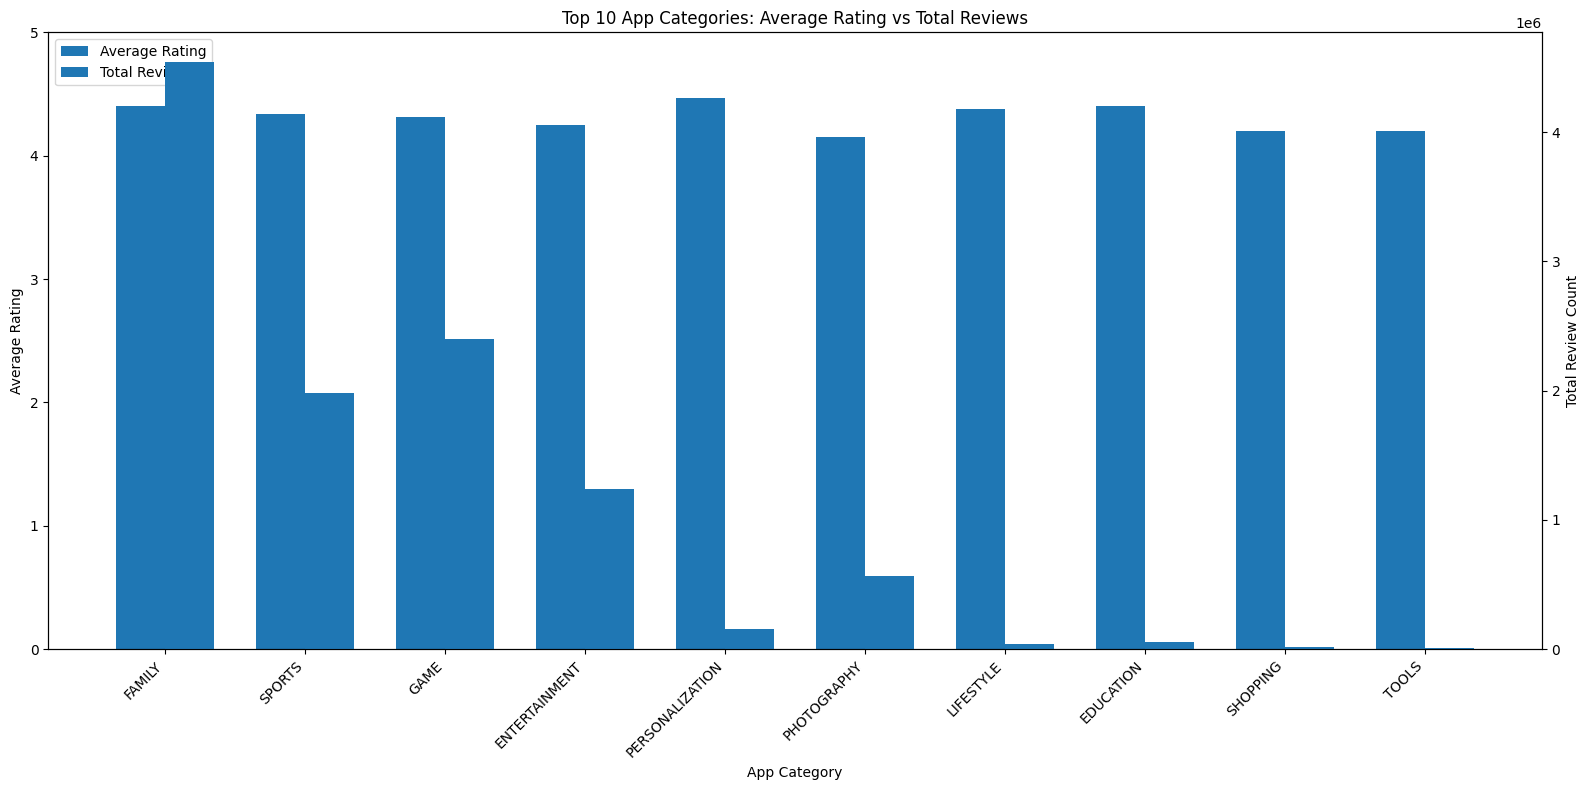

In [20]:
categories = category_metrics["Category"]
ratings = category_metrics["Average_Rating"]
reviews = category_metrics["Total_Reviews"]

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 8))

# Average Rating
ax1.bar(
    x - width / 2,
    ratings,
    width,
    label="Average Rating"
)

ax1.set_xlabel("App Category")
ax1.set_ylabel("Average Rating")
ax1.set_ylim(0, 5)

# Total Reviews
ax2 = ax1.twinx()

ax2.bar(
    x + width / 2,
    reviews,
    width,
    label="Total Reviews"
)

ax2.set_ylabel("Total Review Count")

ax1.set_xticks(x)
ax1.set_xticklabels(
    categories,
    rotation=45,
    ha="right"
)

plt.title("Top 10 App Categories: Average Rating vs Total Reviews")

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper left"
)

plt.tight_layout()

# Save chart
plt.savefig(
    "grouped_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
# Apply only Size and January filters first
filtered_df = df[
    (df["Size_MB"] >= 10) &
    (df["Last Updated"].dt.month == 1)
].copy()

# Calculate category-level metrics
category_metrics = (
    filtered_df
    .groupby("Category")
    .agg(
        Average_Rating=("Rating", "mean"),
        Total_Reviews=("Reviews", "sum"),
        Total_Installs=("Installs", "sum")
    )
    .reset_index()
)

# Remove categories with average rating below 4.0
category_metrics = category_metrics[
    category_metrics["Average_Rating"] >= 4.0
].copy()

# Select top 10 categories by total installs
category_metrics = (
    category_metrics
    .sort_values("Total_Installs", ascending=False)
    .head(10)
)

# Round rating
category_metrics["Average_Rating"] = (
    category_metrics["Average_Rating"].round(2)
)

category_metrics

,Category,Average_Rating,Total_Reviews,Total_Installs
9,FAMILY,4.19,4737822.0,199721180.0
25,SPORTS,4.34,1982017.0,120511100.0
12,GAME,4.25,2412245.0,117291000.0
7,ENTERTAINMENT,4.25,1238948.0,51000000.0
20,PERSONALIZATION,4.47,156004.0,15061000.0
15,LIFESTYLE,4.05,53376.0,6171560.0
23,SHOPPING,4.20,19950.0,2000000.0
6,EDUCATION,4.40,57645.0,2000000.0
4,COMMUNICATION,4.05,15398.0,1011000.0
0,ART_AND_DESIGN,4.10,2167.0,620000.0


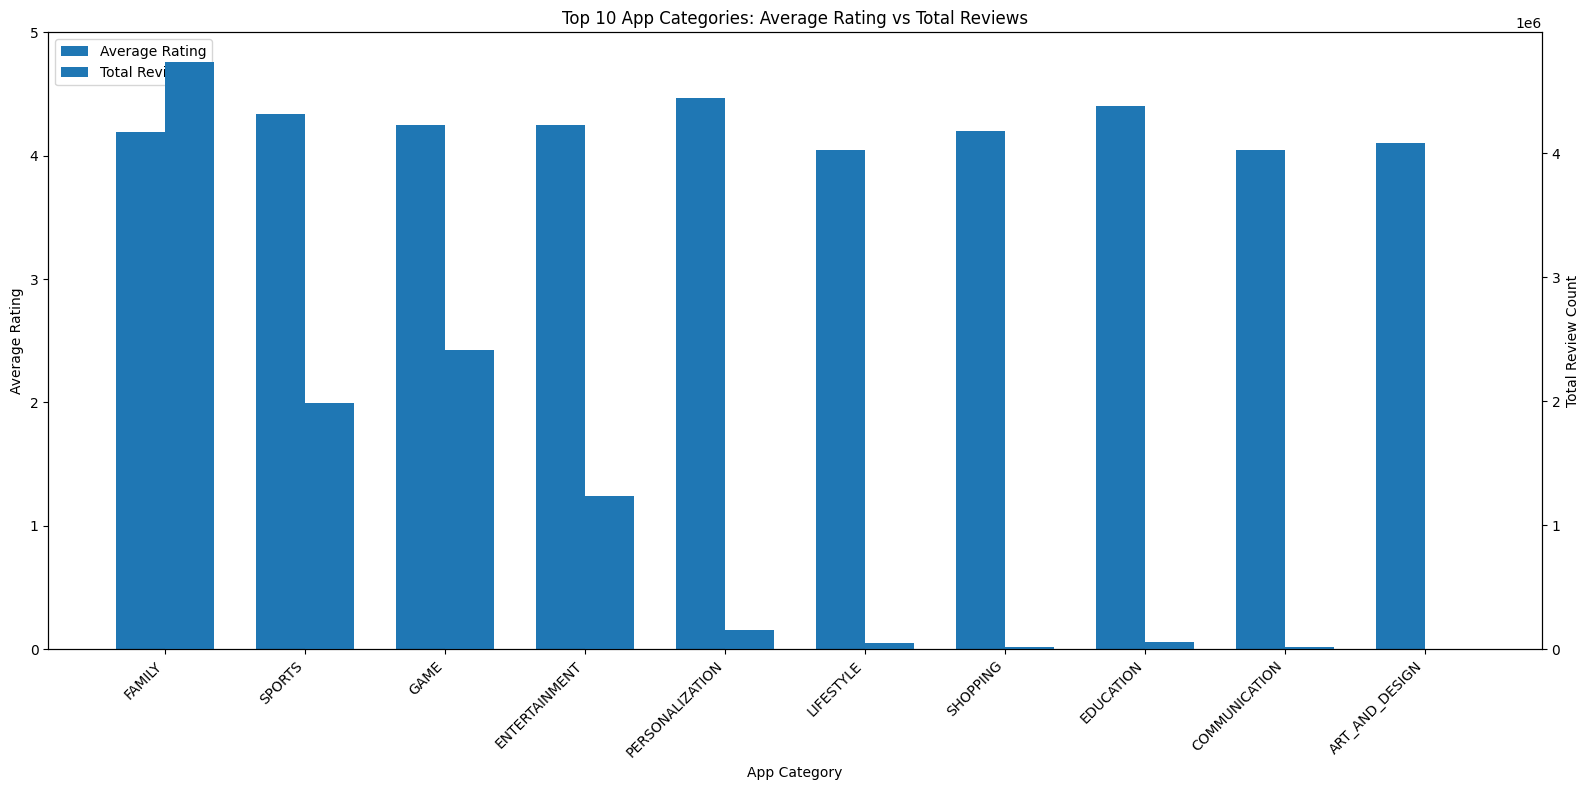

In [22]:
categories = category_metrics["Category"]
ratings = category_metrics["Average_Rating"]
reviews = category_metrics["Total_Reviews"]

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 8))

# Average Rating
bars1 = ax1.bar(
    x - width / 2,
    ratings,
    width,
    label="Average Rating"
)

ax1.set_xlabel("App Category")
ax1.set_ylabel("Average Rating")
ax1.set_ylim(0, 5)

# Total Reviews
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    reviews,
    width,
    label="Total Reviews"
)

ax2.set_ylabel("Total Review Count")

ax1.set_xticks(x)
ax1.set_xticklabels(
    categories,
    rotation=45,
    ha="right"
)

plt.title(
    "Top 10 App Categories: Average Rating vs Total Reviews"
)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "grouped_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

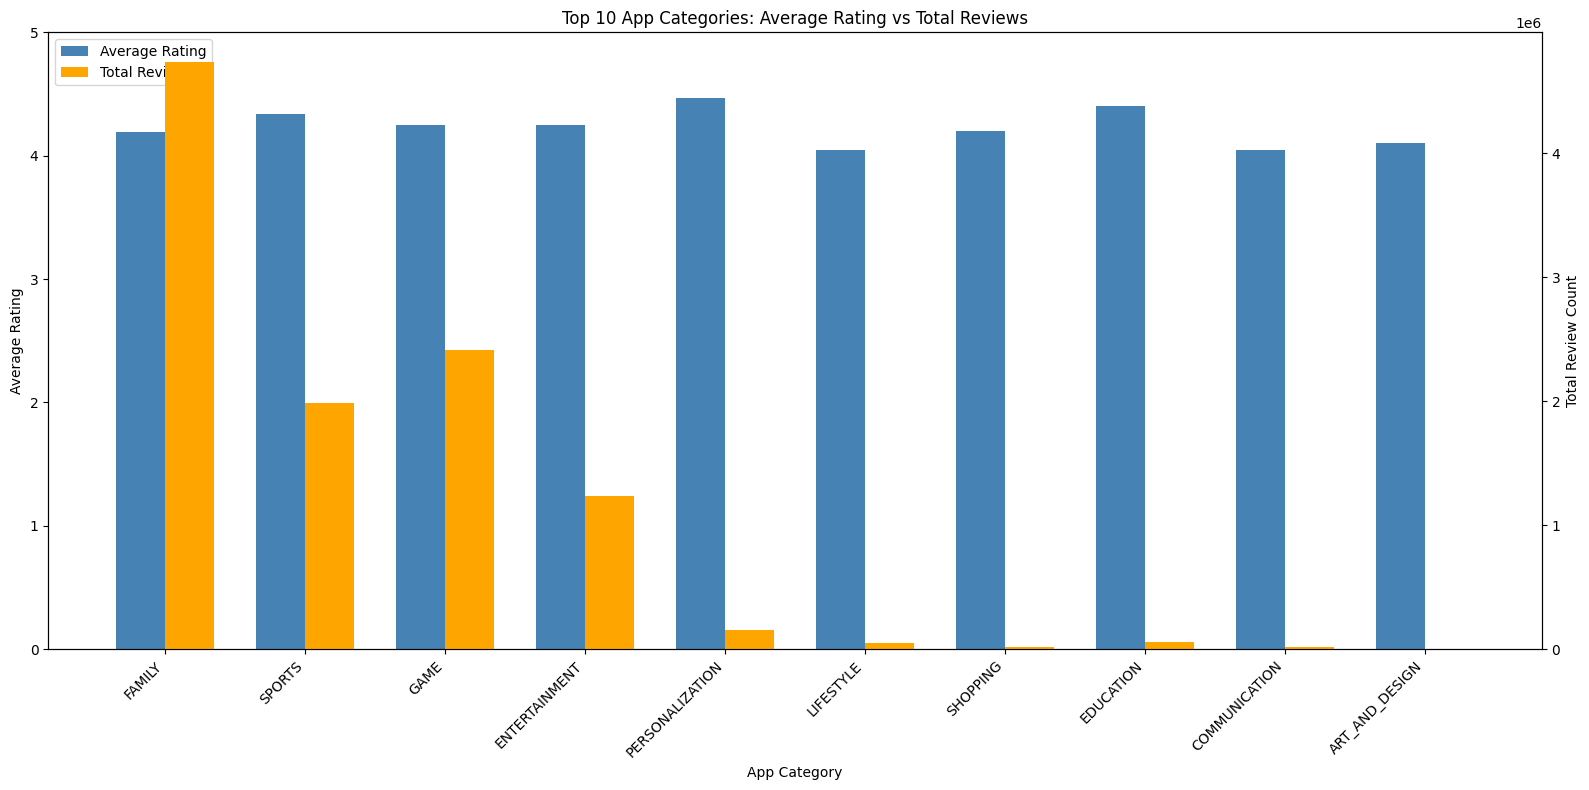

In [23]:
categories = category_metrics["Category"]
ratings = category_metrics["Average_Rating"]
reviews = category_metrics["Total_Reviews"]

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 8))

# Average Rating bars
bars1 = ax1.bar(
    x - width / 2,
    ratings,
    width,
    label="Average Rating",
    color="steelblue"
)

ax1.set_xlabel("App Category")
ax1.set_ylabel("Average Rating")
ax1.set_ylim(0, 5)

# Total Reviews bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    reviews,
    width,
    label="Total Reviews",
    color="orange"
)

ax2.set_ylabel("Total Review Count")

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(
    categories,
    rotation=45,
    ha="right"
)

plt.title(
    "Top 10 App Categories: Average Rating vs Total Reviews"
)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "grouped_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

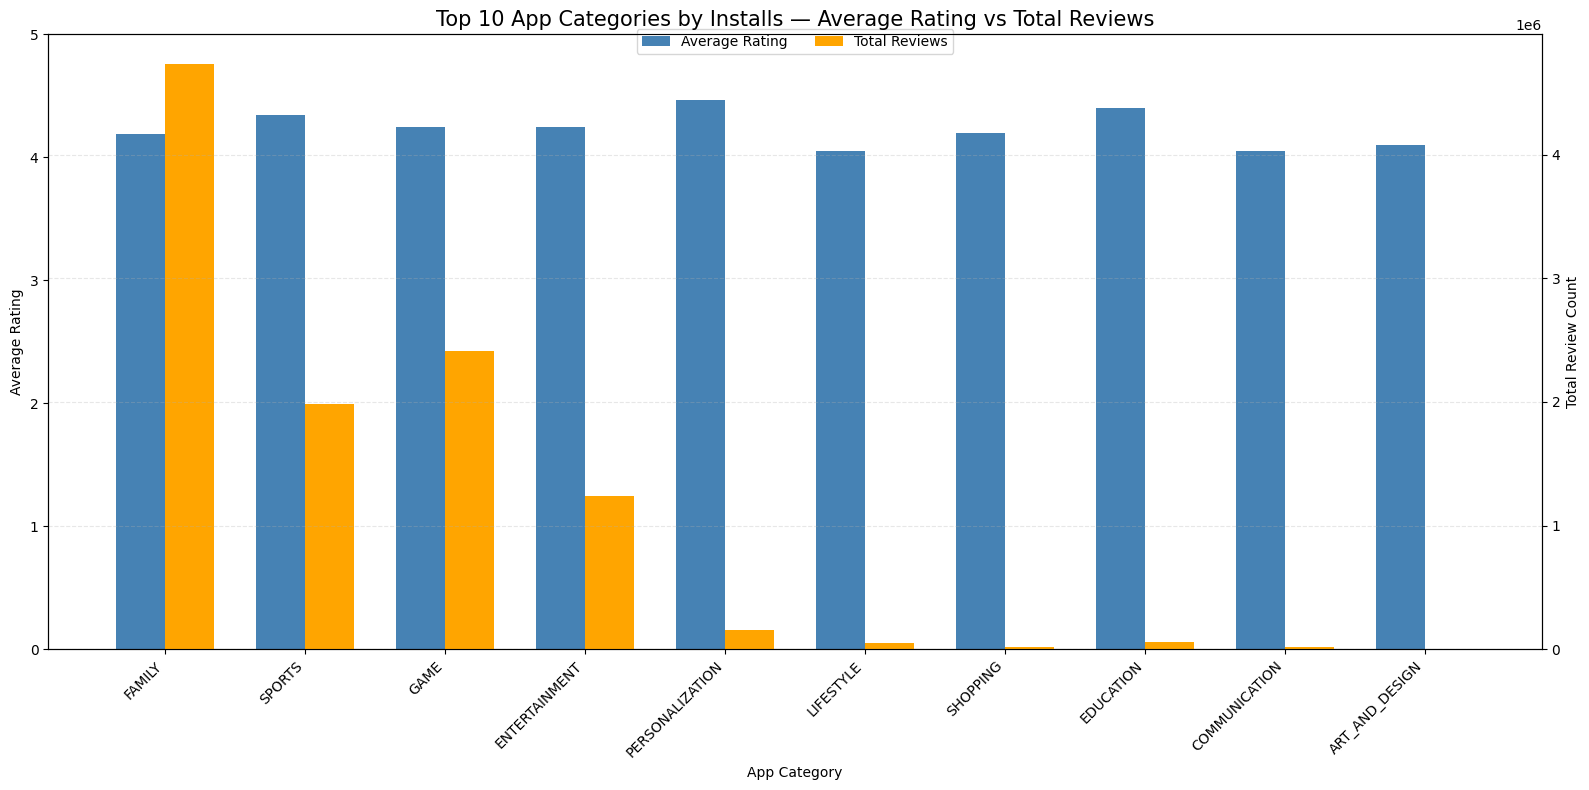

In [24]:
categories = category_metrics["Category"]
ratings = category_metrics["Average_Rating"]
reviews = category_metrics["Total_Reviews"]

x = np.arange(len(categories))
width = 0.35

fig, ax1 = plt.subplots(figsize=(16, 8))

# Average Rating
bars1 = ax1.bar(
    x - width / 2,
    ratings,
    width,
    label="Average Rating",
    color="steelblue"
)

ax1.set_xlabel("App Category")
ax1.set_ylabel("Average Rating")
ax1.set_ylim(0, 5)

# Total Reviews
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    reviews,
    width,
    label="Total Reviews",
    color="orange"
)

ax2.set_ylabel("Total Review Count")

# Display review axis in millions
ax2.ticklabel_format(
    style="sci",
    axis="y",
    scilimits=(6, 6)
)

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(
    categories,
    rotation=45,
    ha="right"
)

# Grid
ax2.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Title
plt.title(
    "Top 10 App Categories by Installs — "
    "Average Rating vs Total Reviews",
    fontsize=15
)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout()

# Save chart
plt.savefig(
    "grouped_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
from datetime import datetime
from zoneinfo import ZoneInfo

# Get current time in IST
current_time = datetime.now(ZoneInfo("Asia/Kolkata"))

# Chart is available only from 3:00 PM to 5:00 PM IST
if 15 <= current_time.hour < 17:

    categories = category_metrics["Category"]
    ratings = category_metrics["Average_Rating"]
    reviews = category_metrics["Total_Reviews"]

    x = np.arange(len(categories))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Average Rating
    bars1 = ax1.bar(
        x - width / 2,
        ratings,
        width,
        label="Average Rating",
        color="steelblue"
    )

    ax1.set_xlabel("App Category")
    ax1.set_ylabel("Average Rating")
    ax1.set_ylim(0, 5)

    # Total Reviews
    ax2 = ax1.twinx()

    bars2 = ax2.bar(
        x + width / 2,
        reviews,
        width,
        label="Total Reviews",
        color="orange"
    )

    ax2.set_ylabel("Total Review Count")

    # Display review axis in millions
    ax2.ticklabel_format(
        style="sci",
        axis="y",
        scilimits=(6, 6)
    )

    # X-axis
    ax1.set_xticks(x)
    ax1.set_xticklabels(
        categories,
        rotation=45,
        ha="right"
    )

    # Grid
    ax2.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # Title
    plt.title(
        "Top 10 App Categories by Installs — "
        "Average Rating vs Total Reviews",
        fontsize=15
    )

    # Combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(
        h1 + h2,
        l1 + l2,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2
    )

    plt.tight_layout()

    # Save chart
    plt.savefig(
        "grouped_bar_chart.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    # Do not display the graph outside the required time
    plt.close("all")

    print(
        "Task 5 chart is available only between "
        "3:00 PM and 5:00 PM IST."
    )

Task 5 chart is available only between 3:00 PM and 5:00 PM IST.
